# Rate vs Acidity

This workbook contains the code and imports the data to reproduce the acid-rate plot for oxime hydrolysis and rearrangement as presented in Figure 1 of the Schfield paper(1).

the data being plotted is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 

I digitized the data from the plot. The data for rearrangement was available in Tablular form as well.

I will be plotting differentials between digitized data and tabular data for rearrangement to compare the plots in the paper to the given values.

I have reused previous notebooks and just added what I needed. There is lots of code here that is not used. Its also a hack job and is not elegant. But it works.

## Setup 

The code below sets global variables and imports needed dependencies.

In [1]:
####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit
import scipy 

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("plots/stacking").mkdir(exist_ok=True)
#Path("plots/single").mkdir(exist_ok=True)
#Path("plots/fits").mkdir(exist_ok=True)

#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M33_Beckmann/data.zip
    !unzip -q data.zip

github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()

style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"
plt.style.use(style_file)        

## Read Experimental Data for Acid Hydrolysis
Here the data from the publication is read in. It had been saved in a csv file. the data is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 


In [2]:
############################################
### Read in data from literature example ###
############################################

datafile = "data/Table1and2All.csv"

df = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")
df["kobs"] = 10**(-4) * df["kobs"]
df["log_k"] = np.log10(df["kobs"])

# filter dataframe for rows where %H2SO4 is 98.2 and TempC is 80
df = df[df['TempC'] == 80]

# Filter data forn a given list of substituents
substituent_list = ["H", "p-CH3", "p-OCH3", "p-NO2", "m-F"]
df = df.loc[substituent_list]


# Edit out two points that for reasons below.
# The p-OCH3 point below was extrapolated and is not reliable
# The p-CH3 point at 95.2 %H2SO4 was not used in the original plot (no explanation given)

df2 = df[(df['%H2SO4'] != 98.2) | (df['Name'] != 'p-Methoxy')]
df2 = df2[(df2['%H2SO4'] != 95.2) | (df2['Name'] != 'p-Methyl')]

df2.sort_values(by=['Substituent','%H2SO4'], inplace=True) # sort df2 by index and by %H2SO4

# reset index after sorting. This is an important step. The index is used to match up the 
#  items in the series when we calculate the differences. The indexes must be the same. 
#  Resetting ensures that this is the case.
df2.reset_index(inplace=True)    

display(df2)

,Substituent,Name,%H2SO4,TempC,kobs,log_k
0,H,Hydrogen,70.1,80.0,0.000008,-5.096910
1,H,Hydrogen,73.9,80.0,0.000017,-4.769551
2,H,Hydrogen,79.3,80.0,0.000038,-4.420216
3,H,Hydrogen,85.8,80.0,0.000106,-3.974694
4,H,Hydrogen,91.7,80.0,0.000280,-3.552842
5,H,Hydrogen,94.8,80.0,0.000570,-3.244125
6,H,Hydrogen,95.2,80.0,0.000610,-3.214670
7,H,Hydrogen,98.2,80.0,0.001700,-2.769551
8,m-F,m-Fluoro,85.8,80.0,0.000029,-4.537602
9,m-F,m-Fluoro,90.4,80.0,0.000069,-4.161151


## Read Digitized Data for Rearrangement

In [3]:
############################################
### Read in data from literature example ###
############################################

datafile = "data/Figure_1_RearrangementRates_Picked.csv"

df3 = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")
#df3.reset_index(inplace=True)
df3.sort_values(by=['Substituent','%H2SO4_Figure'], inplace=True)
df3.reset_index(inplace=True)

display(df3)

,Substituent,%H2SO4_paper,%H2SO4_Figure,log_k_Figure
0,H,70.1,70.177,-5.0938
1,H,73.9,73.929,-4.7723
2,H,79.3,78.344,-4.4241
3,H,85.8,85.894,-3.9777
4,H,91.7,91.854,-3.5625
5,H,94.8,94.857,-3.2634
6,H,95.2,95.342,-3.2232
7,H,98.2,98.300,-2.7902
8,m-F,85.8,85.938,-4.5491
9,m-F,90.4,90.486,-4.1786


## Figure 17: Differential Plot

Mean x-axis devation is 0.0766 +/- 0.0481
Mean y-axis devation is -0.0094 +/- 0.00891


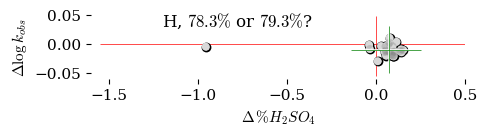

In [4]:
x_exp = df2['%H2SO4']
y_exp = df2['log_k']
x_picked = df3['%H2SO4_Figure']
y_picked = df3['log_k_Figure']

dx = x_picked - x_exp
dy = y_picked - y_exp

#print(dx)
##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.5))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

ax.scatter(dx,dy, s = 32, color="white",  edgecolors = "black", zorder=2, linewidths=1.4)
ax.scatter(dx,dy, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
ax.scatter(dx,dy, s = 32, color="gray",  edgecolors = "none", alpha = 0.3, zorder=4)

############################
### Set labels and scale ###
############################

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\Delta\log{k_{obs}}$", 
          xlabel=r"$\Delta\,\% H_2SO_4$",                
          xlim=[-1.6,0.5],                  
          ylim=[-.06,.05],
#          xticks = ( -0.05,0, 0.05, 0.10,0.15),
#          xlim=[-.55,.10],                  
#          ylim=[-.03,.03],
#          xticks = ( -0.5,-0.4,-0.3,-0.2,-0.1,0, 0.10),
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center

ax.hlines(y=0, xmin=-1.55, xmax=0.5, 
          colors='red', linestyles='solid', 
          zorder=0, linewidth=0.5)
ax.vlines(x=0, ymin=-0.055, ymax=0.05, 
          colors='red', linestyles='solid', 
          zorder=0, linewidth=0.5)

ax.text(-1.2, 0.030, r"H, $78.3\%$ or $79.3\%$?", fontsize=12)

# add mean and st_dev info
# remove lowest value from dx array (the outlier on x-axis)
dx_temp = np.delete(dx, dx.argmin())
meanx = np.mean(dx_temp)
st_devx = np.std(dx_temp)
print(f"Mean x-axis devation is {meanx:0.3g} +/- {st_devx:0.3g}")

meany = np.mean(dy)
st_devy = np.std(dy)
print(f"Mean y-axis devation is {meany:0.3g} +/- {st_devy:0.3g}")

ax.hlines(y=meany, xmin=np.min(dx_temp)-0.1, xmax=np.max(dx_temp)+0.1, 
          colors='white', linestyles='solid', alpha = 0.8,
          zorder=7, linewidth=1.5)
ax.hlines(y=meany, xmin=np.min(dx_temp)-0.1, xmax=np.max(dx_temp)+0.1, 
          colors='green', linestyles='solid', 
          zorder=8, linewidth=0.5)
ax.vlines(x=meanx, ymin=np.min(dy)-0.02, ymax=np.max(dy)+0.02, 
          colors='white', linestyles='solid', alpha = 0.8, 
          zorder=7, linewidth=1.5)
ax.vlines(x=meanx, ymin=np.min(dy)-0.02, ymax=np.max(dy)+0.02, 
          colors='green', linestyles='solid', 
          zorder=8, linewidth=0.5)

fig.savefig("plots/Fig_17_diffs.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots




## Figure 18. rate vs acidity from Fig 1 of paper

In [5]:
############################################
### Read in data from literature example ###
############################################

datafile = "data/Table1and2All.csv"

dfq = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")
dfq["kobs"] = 10**(-4) * dfq["kobs"]
dfq["log_k"] = np.log10(dfq["kobs"])

# filter dataframe for rows where %H2SO4 is 98.2 and TempC is 80
dfq = dfq[dfq['TempC'] == 80]

# Filter data for a given list of substituents
substituent_list = ["H", "p-CH3", "p-OCH3", "p-NO2", "m-F"]
dfq = dfq.loc[substituent_list]


# Edit out two points that for reasons below.
# The p-OCH3 point below was extrapolated and is not reliable
# The p-CH3 point at 95.2 %H2SO4 was not used in the original plot (no explanation given)

dfz = dfq[(dfq['%H2SO4'] == 98.2) & (dfq['Name'] == 'p-Methoxy')]
print(dfz)
dfq = dfq[(dfq['%H2SO4'] != 98.2) | (dfq['Name'] != 'p-Methoxy')]

# I'm going to keep this methyl point in my own plot. Why did the authors' ignore it? We will see...
#df2 = df2[(df2['%H2SO4'] != 95.2) | (df2['Name'] != 'p-Methyl')]

# note I changed df2 to dfx here to avoid a wierd error about 'copies and views' that I don't understand.
dfx = dfq.sort_values(by=['Substituent','%H2SO4'], inplace=False) # sort df2 by index and by %H2SO4

# reset index after sorting. This is an important step. The index is used to match up the 
#  items in the series when we calculate the differences. The indexes must be the same. 
#  Resetting ensures that this is the case.
dfx.reset_index(inplace=True)    

display(dfx)

# plot the data for each substituent in dfx separately


                  Name  %H2SO4  TempC   kobs    log_k
Substituent                                          
p-OCH3       p-Methoxy    98.2   80.0  0.004 -2.39794


,Substituent,Name,%H2SO4,TempC,kobs,log_k
0,H,Hydrogen,70.1,80.0,0.000008,-5.096910
1,H,Hydrogen,73.9,80.0,0.000017,-4.769551
2,H,Hydrogen,79.3,80.0,0.000038,-4.420216
3,H,Hydrogen,85.8,80.0,0.000106,-3.974694
4,H,Hydrogen,91.7,80.0,0.000280,-3.552842
5,H,Hydrogen,94.8,80.0,0.000570,-3.244125
6,H,Hydrogen,95.2,80.0,0.000610,-3.214670
7,H,Hydrogen,98.2,80.0,0.001700,-2.769551
8,m-F,m-Fluoro,85.8,80.0,0.000029,-4.537602
9,m-F,m-Fluoro,90.4,80.0,0.000069,-4.161151


H marker is s, black
[ 8.32463240e-04 -6.29838370e-02 -4.71258496e+00]
m-F marker is ^, purple
[ 4.47122283e-03 -7.17446596e-01  2.41161756e+01]
p-CH3 marker is D, red
[ 9.09692351e-04 -8.00911264e-02 -3.54906825e+00]
p-NO2 marker is v, green
[ 4.36714292e-03 -6.90143880e-01  2.15797991e+01]
p-OCH3 marker is o, blue
[ 7.32425416e-04 -6.39071409e-02 -3.51991077e+00]


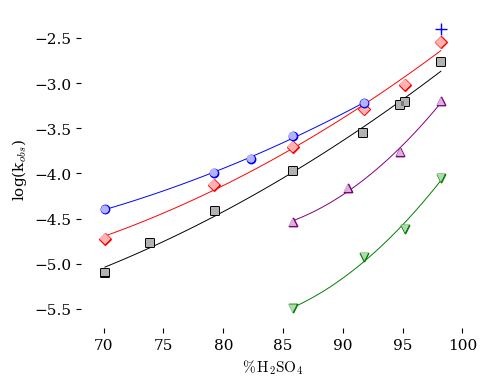

In [6]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


# plot the data for each substituent separately
sub_array = dfx['Substituent'].unique()        # list of substituents

symbol_list = ['s', '^', 'D', 'v', 'o', "s"]   # list of marker styles 
symbol_list = symbol_list[0:len(sub_array)]    # trim list to length of substituent list

color_list = ['black', 'purple', 'red', 'green', 'blue', 'black'] # list of colors for each marker
color_list = color_list[0:len(sub_array)]      # trim list to length of substituent list

# convert these lists into a dataframe
plot_style_df = pd.DataFrame({"Substituent":sub_array,
                              "marker": symbol_list,
                              "color": color_list}, index = sub_array)
#display(plot_style_df)
# plot each set of data for a substituent with a different symbol
for sub in plot_style_df['Substituent']:
    color = plot_style_df['color'].loc[sub]
    marker = plot_style_df['marker'].loc[sub]
    print(sub + " marker is " + marker + ", " + color)

    df_sub = dfx[dfx['Substituent']==sub].copy()
    x = df_sub['%H2SO4']
    y = df_sub['log_k']

    ax.scatter(x,y, s = 32, color = 'white', edgecolor = color, marker = marker, linewidths = 1.4)
    ax.scatter(x,y, s = 32, color = 'white', edgecolor = "none", marker = marker)
    ax.scatter(x,y, s = 32, color = color, edgecolor = "none", marker = marker, alpha = 0.3)

    result = np.polyfit(x, y, 2, rcond=None, full=False, w=None, cov=False)

    x_fit = np.linspace(x.min(), x.max(), 50)
    p = np.poly1d(result)
    y_fit = np.polyval(p, x_fit)

    ax.plot(x_fit, y_fit, linewidth = 0.7, color = color, zorder = 0)
    print(result)

ax.scatter(dfz['%H2SO4'], dfz['log_k'], s=64, marker = '+', color = 'blue')

# finalize plot settings
ax.set_xlabel(r'$\%\,\rm H_2SO_4$')
ax.set_ylabel('log(k$_{obs}$)')
#ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
#ax.set_ylim(-16.5,-1.5)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

plt.savefig('plots/Fig_18_acid_rate_Fig_1.pdf')
plt.show()

## Read Digitized Data for Oxime Hydrolysis

In [7]:
############################################
### Read in data from literature example ###
############################################

datafile = "data/Figure_1_HydrolysisRates_Picked.csv"

df_h = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")

df_h.sort_values(by=['Substituent','%H2SO4_Figure'], inplace=True)
df_h.reset_index(inplace=True)

display(df_h)

,Substituent,%H2SO4_paper,%H2SO4_Figure,log_k_Figure
0,H,NaN,50.486,-2.2366
1,H,NaN,54.238,-2.3929
2,H,NaN,60.817,-2.7946
3,H,NaN,65.717,-3.1741
4,H,70.1,70.309,-3.7054
5,H,73.9,74.018,-4.2008
6,H,79.3,79.404,-5.0045
7,p-NO2,NaN,60.817,-2.4286
8,p-NO2,70.1,70.221,-3.1027
9,p-NO2,85.8,85.850,-5.1071


<StringArray>
['H', 'p-NO2', 'p-OCH3']
Length: 3, dtype: str
H marker is s, black
[-2.38725688e-03  2.14720724e-01 -7.00366454e+00]
p-NO2 marker is v, green
[-2.25967744e-03  2.24421350e-01 -7.71934736e+00]
p-OCH3 marker is o, blue
[-2.81553715e-03  2.72663562e-01 -9.26872155e+00]


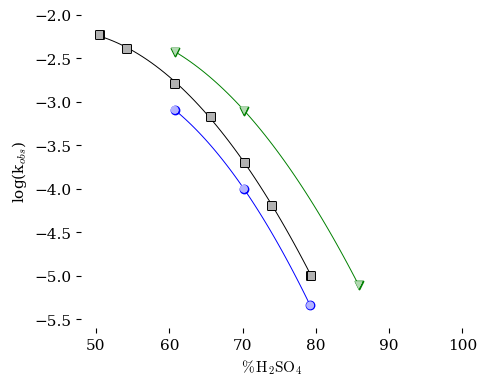

In [8]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


# plot the data for each substituent separately
sub_array = df_h['Substituent'].unique()        # list of substituents
print(sub_array)
symbol_list = ['s', 'v', 'o', '^', 'D', "s"]   # list of marker styles 
symbol_list = symbol_list[0:len(sub_array)]    # trim list to length of substituent list

color_list = ['black', 'green', 'blue', 'purple', 'red', 'black'] # list of colors for each marker
color_list = color_list[0:len(sub_array)]      # trim list to length of substituent list

# convert these lists into a dataframe
plot_style_df = pd.DataFrame({"Substituent":sub_array,
                              "marker": symbol_list,
                              "color": color_list}, index = sub_array)
#display(plot_style_df)
# plot each set of data for a substituent with a different symbol
for sub in plot_style_df['Substituent']:
    color = plot_style_df['color'].loc[sub]
    marker = plot_style_df['marker'].loc[sub]
    print(sub + " marker is " + marker + ", " + color)

    df_sub = df_h[df_h['Substituent']==sub].copy()

    x = df_sub['%H2SO4_Figure']
    y = df_sub['log_k_Figure']

    ax.scatter(x,y, s = 32, color = 'white', edgecolor = color, marker = marker, linewidths = 1.4)
    ax.scatter(x,y, s = 32, color = 'white', edgecolor = "none", marker = marker)
    ax.scatter(x,y, s = 32, color = color, edgecolor = "none", marker = marker, alpha = 0.3)

    result = np.polyfit(x, y, 2, rcond=None, full=False, w=None, cov=False)

    x_fit = np.linspace(x.min(), x.max(), 50)
    p = np.poly1d(result)
    y_fit = np.polyval(p, x_fit)

    ax.plot(x_fit, y_fit, linewidth = 0.7, color = color, zorder = 0)
    print(result)


# finalize plot settings
ax.set_xlabel(r'$\%\,\rm H_2SO_4$')
ax.set_ylabel('log(k$_{obs}$)')
#ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
ax.set_ylim(-5.6,-2.)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
ax.set_xticks([50,60,70,80,90,100])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

plt.savefig('plots/Fig_19_acid_rate_Fig_1.pdf')
plt.show()